#Kavish Nag
#24070126085
#AIML B1

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn import metrics

In [31]:
df = pd.read_csv("/content/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [33]:
df = df.drop(columns=['Id'])

X = df.drop(columns=['quality'], errors='ignore')

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

print("\nDBSCAN Labels:")
print(np.unique(db_labels))


DBSCAN Labels:
[-1  0  1]


In [36]:
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)
print("\nAgglomerative Labels:")
print(np.unique(agg_labels))



Agglomerative Labels:
[0 1 2]


In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [41]:
#DBSCAN
# Remove noise points (-1) for fair evaluation
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    sil_db = silhouette_score(X_scaled[mask], db_labels[mask])
    dbi_db = davies_bouldin_score(X_scaled[mask], db_labels[mask])
    chi_db = calinski_harabasz_score(X_scaled[mask], db_labels[mask])

    print("\nDBSCAN Performance:")
    print("Silhouette Score:", sil_db)
    print("Davies-Bouldin Index:", dbi_db)
    print("Calinski-Harabasz Index:", chi_db)
else:
    print("\nDBSCAN: Not enough clusters for evaluation")


DBSCAN Performance:
Silhouette Score: 0.5534618301862813
Davies-Bouldin Index: 0.5099064044736028
Calinski-Harabasz Index: 71.18458321294773


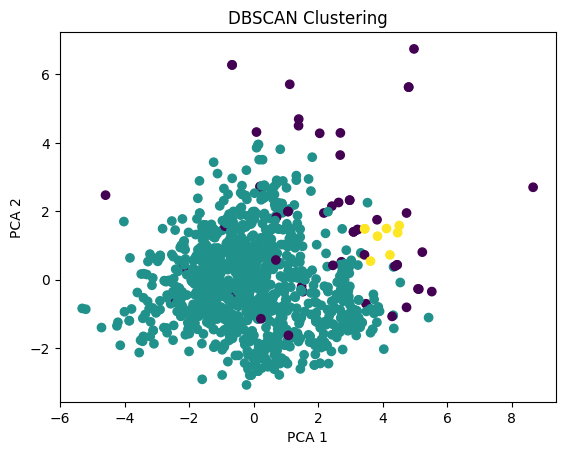

In [38]:
#DBCAN
plt.figure()
plt.title("DBSCAN Clustering")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [42]:
#AGGLOMERATIVE
sil_agg = silhouette_score(X_scaled, agg_labels)
dbi_agg = davies_bouldin_score(X_scaled, agg_labels)
chi_agg = calinski_harabasz_score(X_scaled, agg_labels)

print("\nAgglomerative Performance:")
print("Silhouette Score:", sil_agg)
print("Davies-Bouldin Index:", dbi_agg)
print("Calinski-Harabasz Index:", chi_agg)


Agglomerative Performance:
Silhouette Score: 0.12957587441686894
Davies-Bouldin Index: 2.0488616716507013
Calinski-Harabasz Index: 176.44437267268498


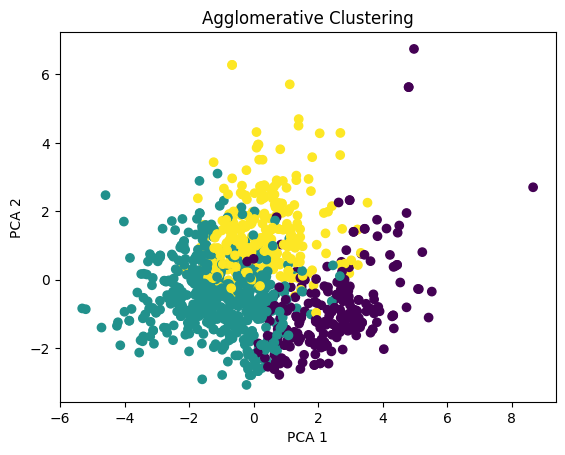

In [39]:
#Agglomerative
plt.figure()
plt.title("Agglomerative Clustering")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()